In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap

In [280]:
data_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\Climbing_New"
transgenic = "MB112C x Chrimson2"
fly_number = 75
start_color = "#a8ddb4"
end_color = "#007000"


df = pd.read_csv(data_path + "/" + transgenic + ".csv")
genotype = [c.rsplit(' X_', 1)[0] for c in df.columns if ' X_' in c][0]
xcol = f"{genotype} X_{fly_number}"
ycol = f"{genotype} Y_{fly_number}"

print(f"Loaded {transgenic}, total " + str((len(df.columns)-3)/2))

Loaded MB112C x Chrimson2, total 83.0


## single color, time progression

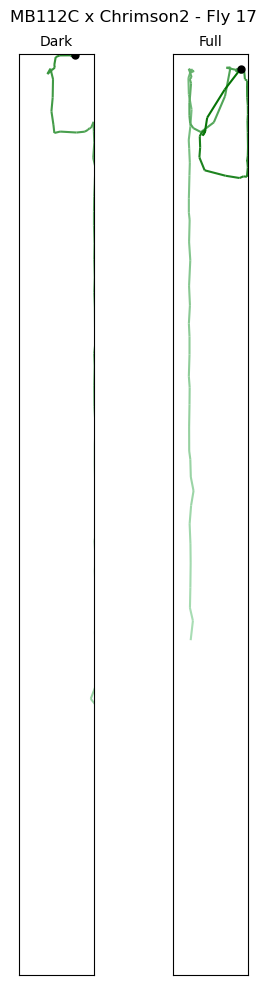

In [156]:
cmap = LinearSegmentedColormap.from_list('custom', [start_color, end_color])
fig, axes = plt.subplots(1, 2, figsize=(4, 10))

for idx, state in enumerate(['Dark', 'Full']):
    ax = axes[idx]
    sub = df[df['ExperimentState'] == state]
    x = sub[xcol].values
    y = sub[ycol].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    if len(x) > 1:
        t = np.linspace(0, 1, len(x))
        points = np.column_stack([x, y]).reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=Normalize(0, 1), linewidths=1.5)
        lc.set_array(t[:-1])
        ax.add_collection(lc)
        ax.plot(x[-1], y[-1], 'o', color="#000000", markersize=5, zorder=5)

    ax.set_xlim(0, 7)
    ax.set_ylim(0, 86)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{state}', fontsize=10)

fig.suptitle(f'{transgenic} - Fly {fly_number}', fontsize=12)
plt.tight_layout()
plt.show()

## speed

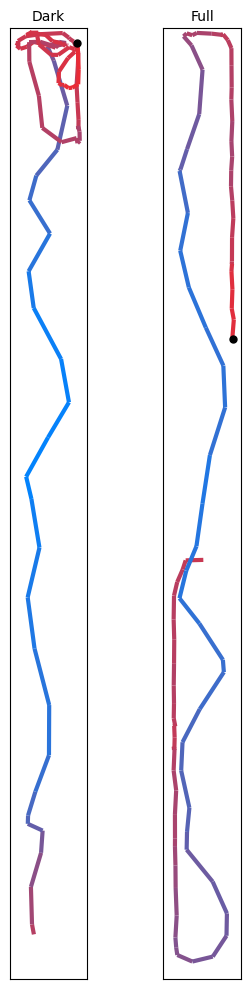

In [283]:
speed_min = 0
speed_max = 20
smooth_window = 15

speed_cmap = LinearSegmentedColormap.from_list('speed', ["#FF2323FF", "#0084FF"])
fig, axes = plt.subplots(1, 2, figsize=(4, 10))

for idx, state in enumerate(['Dark', 'Full']):
    ax = axes[idx]
    sub = df[df['ExperimentState'] == state]
    x = sub[xcol].values
    y = sub[ycol].values
    t = sub['Seconds'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y, t = x[mask], y[mask], t[mask]

    if len(x) > 1:
        dt = np.diff(t)
        dt[dt == 0] = np.nan
        speed = np.sqrt(np.diff(x)**2 + np.diff(y)**2) / dt
        speed = np.nan_to_num(speed, nan=0.0)
        kernel = np.ones(smooth_window) / smooth_window
        speed = np.convolve(speed, kernel, mode='same')
        points = np.column_stack([x, y]).reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=speed_cmap, norm=Normalize(speed_min, speed_max), linewidths=3)
        lc.set_array(speed)
        ax.add_collection(lc)
        ax.plot(x[-1], y[-1], 'o', color="#000000", markersize=5, zorder=5)

    ax.set_xlim(0, 7)
    ax.set_ylim(0, 86)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{state}', fontsize=10)

#fig.suptitle(f'{transgenic} - Fly {fly_number} (Speed)', fontsize=12)
plt.tight_layout()
plt.show()